<a href="https://colab.research.google.com/github/ChAbid-773/Bike_Regresssion/blob/main/Bike_Regresssion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import sklearn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

In [84]:
seoul_bike_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00560/SeoulBikeData.csv'
dataset_cols=["bike_count","hour","temp","humidity","wind","visibility","dew_pt_temp","radiation","rain","snow","functional"]

df = pd.read_csv(seoul_bike_url, encoding='ISO-8859-1').drop(["Date","Holiday","Seasons"],axis=1)

In [85]:
df.columns=dataset_cols

In [86]:
df.head()

,bike_count,hour,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Yes


In [87]:
df['functional'] = df['functional'].apply(lambda x: 1 if x == 'Yes' else 0)

In [88]:
df.head()

,bike_count,hour,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1


In [89]:
print(df.info())
print('\nMissing values:\n', df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   bike_count   8760 non-null   int64  
 1   hour         8760 non-null   int64  
 2   temp         8760 non-null   float64
 3   humidity     8760 non-null   int64  
 4   wind         8760 non-null   float64
 5   visibility   8760 non-null   int64  
 6   dew_pt_temp  8760 non-null   float64
 7   radiation    8760 non-null   float64
 8   rain         8760 non-null   float64
 9   snow         8760 non-null   float64
 10  functional   8760 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 752.9 KB
None

Missing values:
 bike_count     0
hour           0
temp           0
humidity       0
wind           0
visibility     0
dew_pt_temp    0
radiation      0
rain           0
snow           0
functional     0
dtype: int64


In [90]:
columns_to_convert_to_int_additional = ['temp', 'wind', 'dew_pt_temp','radiation','rain','snow']

for col in columns_to_convert_to_int_additional:
    if col in df.columns:
        if (df[col] == df[col].astype(int)).all():
            df[col] = df[col].astype('int64')
        else:
            df[col] = df[col].astype('int64')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   bike_count   8760 non-null   int64
 1   hour         8760 non-null   int64
 2   temp         8760 non-null   int64
 3   humidity     8760 non-null   int64
 4   wind         8760 non-null   int64
 5   visibility   8760 non-null   int64
 6   dew_pt_temp  8760 non-null   int64
 7   radiation    8760 non-null   int64
 8   rain         8760 non-null   int64
 9   snow         8760 non-null   int64
 10  functional   8760 non-null   int64
dtypes: int64(11)
memory usage: 752.9 KB


In [92]:
X = df.drop('bike_count', axis=1)
y = df['bike_count']

#*Training , Validation , Test DataSets*

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled shape: (6132, 10)
X_val_scaled shape: (1314, 10)
X_test_scaled shape: (1314, 10)
y_train shape: (6132,)
y_val shape: (1314,)
y_test shape: (1314,)


# Linear Regression Model

Let's start by training a simple Linear Regression model, evaluate its performance using metrics like Mean Squared Error and R-squared, and visualize its predictions.

Linear Regression - Mean Squared Error: 197340.52
Linear Regression - R-squared: 0.51


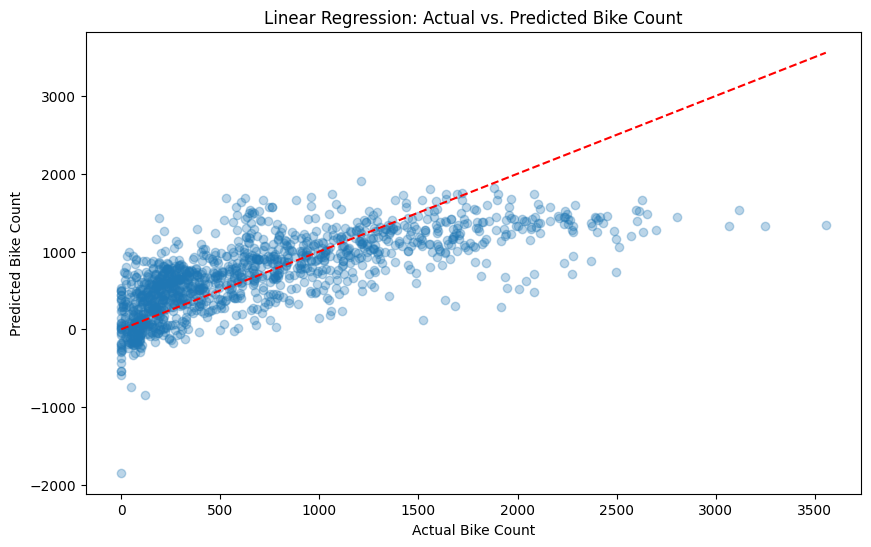

In [94]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_scaled)

# Evaluate the model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression - Mean Squared Error: {mse_linear:.2f}")
print(f"Linear Regression - R-squared: {r2_linear:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('Linear Regression: Actual vs. Predicted Bike Count')
plt.show()

# Polynomial Regression Model

Next, let's try Polynomial Regression to model potential non-linear relationships between features and the target variable.

Polynomial Regression (degree=2) - Mean Squared Error: 152195.89
Polynomial Regression (degree=2) - R-squared: 0.62


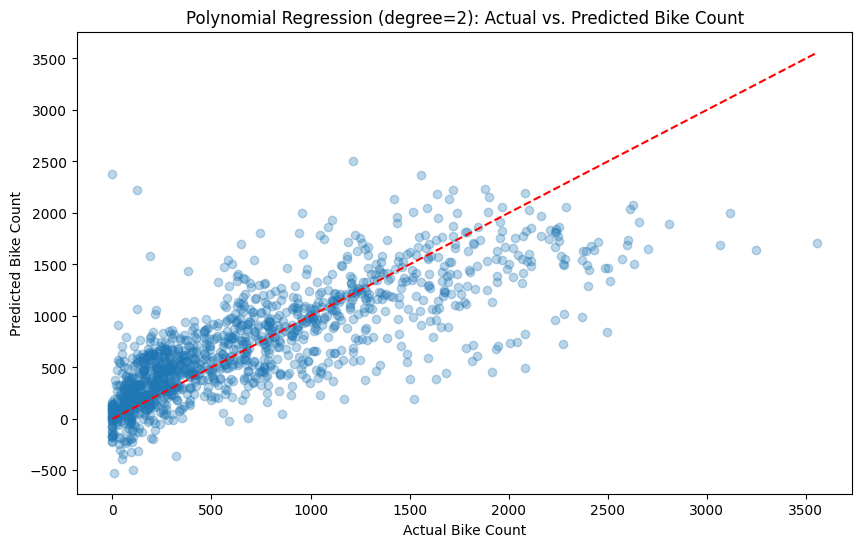

In [95]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features (e.g., degree 2)
degree = 2
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Train Linear Regression model on polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Make predictions on the test set
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate the model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression (degree={degree}) - Mean Squared Error: {mse_poly:.2f}")
print(f"Polynomial Regression (degree={degree}) - R-squared: {r2_poly:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title(f'Polynomial Regression (degree={degree}): Actual vs. Predicted Bike Count')
plt.show()

# K-Nearest Neighbors (KNN) Regression Model

Let's implement the K-Nearest Neighbors (KNN) algorithm for regression. KNN is a non-parametric method used for classification and regression. In KNN regression, the output is the property value for the object, which is the average of the values of its k nearest neighbors.

KNN Regression (n_neighbors=5) - Mean Squared Error: 106675.65
KNN Regression (n_neighbors=5) - R-squared: 0.74


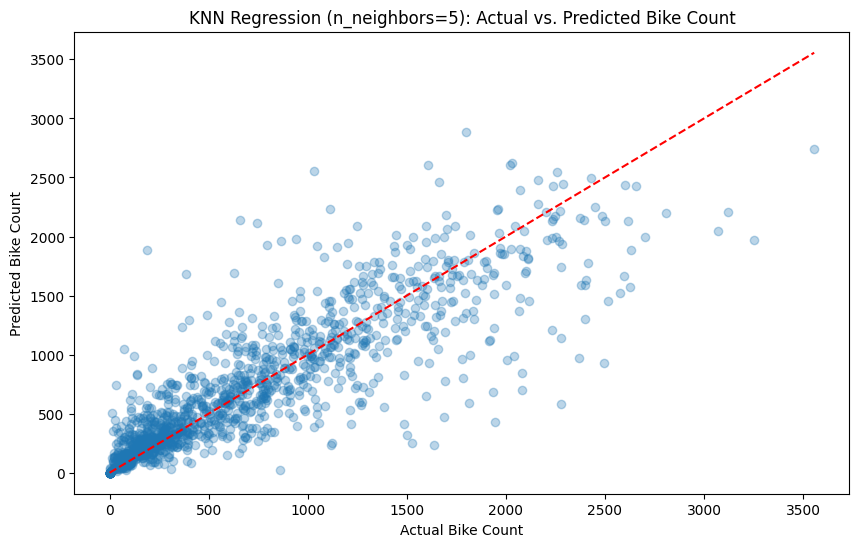

In [96]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize and train the KNN Regressor model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate the model
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"KNN Regression (n_neighbors=5) - Mean Squared Error: {mse_knn:.2f}")
print(f"KNN Regression (n_neighbors=5) - R-squared: {r2_knn:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title(f'KNN Regression (n_neighbors=5): Actual vs. Predicted Bike Count')
plt.show()

# Decision Tree Regression Model

Let's implement the Decision Tree Regressor. Decision trees are non-parametric supervised learning methods used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

Decision Tree Regression - Mean Squared Error: 118820.94
Decision Tree Regression - R-squared: 0.71


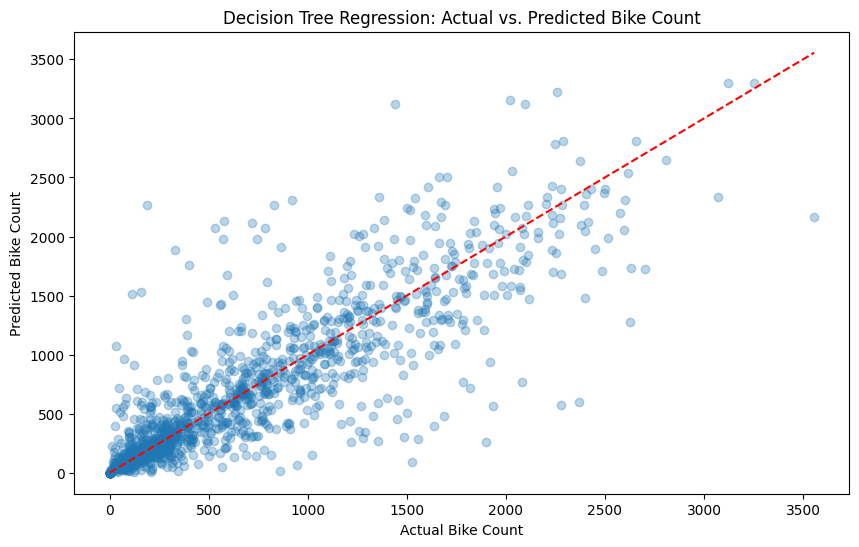

In [97]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regression - Mean Squared Error: {mse_dt:.2f}")
print(f"Decision Tree Regression - R-squared: {r2_dt:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('Decision Tree Regression: Actual vs. Predicted Bike Count')
plt.show()

# Random Forest Regression Model

Now, let's train a Random Forest Regressor. Random Forests are an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the mean prediction of the individual trees.

Random Forest Regression - Mean Squared Error: 68092.11
Random Forest Regression - R-squared: 0.83


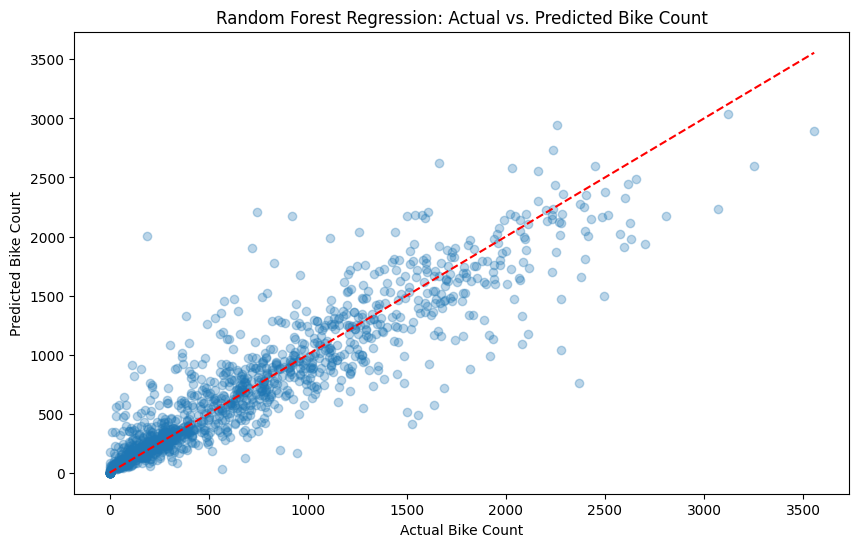

In [98]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf);
r2_rf = r2_score(y_test, y_pred_rf);

print(f"Random Forest Regression - Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest Regression - R-squared: {r2_rf:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('Random Forest Regression: Actual vs. Predicted Bike Count')
plt.show()

# Support Vector Regression (SVR) Model

Assuming 'JVM' was a typo for 'SVM', let's implement Support Vector Regression (SVR). SVR is a powerful algorithm that can model complex non-linear relationships by mapping the data into a higher-dimensional feature space. It aims to find a function that deviates from the target by no more than a certain epsilon, while also being as flat as possible.

Support Vector Regression (Linear Kernel) - Mean Squared Error: 211817.85
Support Vector Regression (Linear Kernel) - R-squared: 0.48


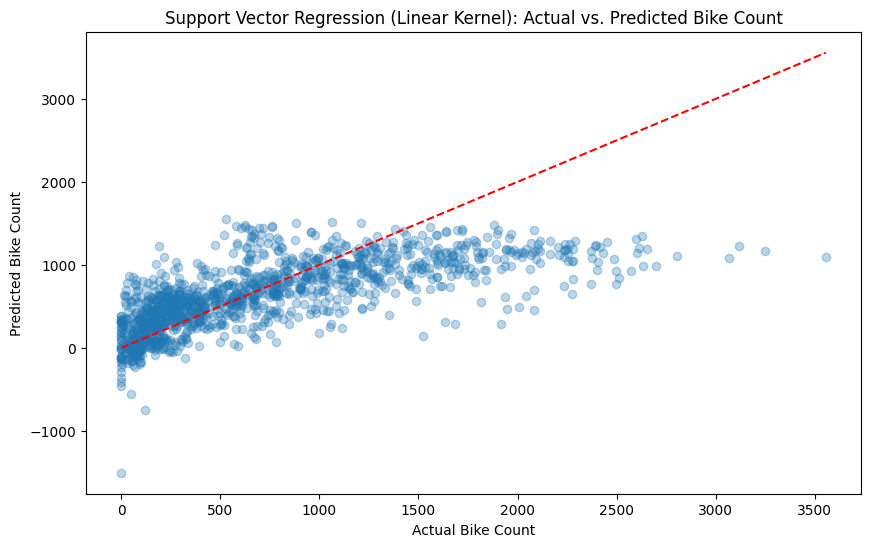

In [99]:
from sklearn.svm import SVR

# Initialize and train the SVR model
sup_vec_model = SVR(kernel='linear')
sup_vec_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_svr = sup_vec_model.predict(X_test_scaled)

# Evaluate the model
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"Support Vector Regression (Linear Kernel) - Mean Squared Error: {mse_svr:.2f}")
print(f"Support Vector Regression (Linear Kernel) - R-squared: {r2_svr:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('Support Vector Regression (Linear Kernel): Actual vs. Predicted Bike Count')
plt.show()

# Bagging Regression Model

Let's implement a Bagging Regressor. Bagging (Bootstrap Aggregating) is an ensemble meta-algorithm that improves the stability and accuracy of machine learning algorithms. It reduces variance and helps to avoid overfitting by training multiple base models (often Decision Trees) on different random subsets of the training data and then averaging their predictions.

Bagging Regression - Mean Squared Error: 68693.87
Bagging Regression - R-squared: 0.83


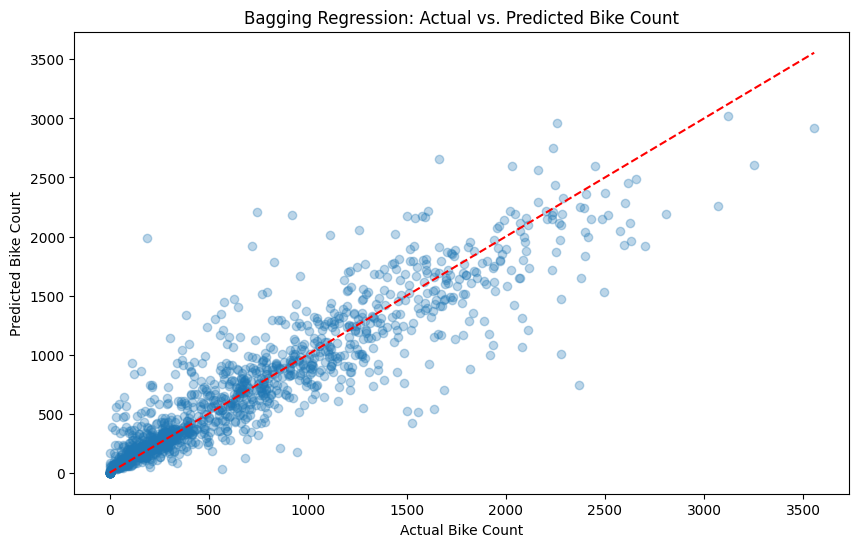

In [100]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

# Initialize a base estimator (e.g., Decision Tree Regressor)
base_estimator = DecisionTreeRegressor(random_state=42)

# Initialize and train the Bagging Regressor model
bagging_model = BaggingRegressor(estimator=base_estimator, n_estimators=100, random_state=42)
bagging_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_bagging = bagging_model.predict(X_test_scaled)

# Evaluate the model
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
r2_bagging = r2_score(y_test, y_pred_bagging)

print(f"Bagging Regression - Mean Squared Error: {mse_bagging:.2f}")
print(f"Bagging Regression - R-squared: {r2_bagging:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_bagging, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('Bagging Regression: Actual vs. Predicted Bike Count')
plt.show()

### Boosting Models: XGBoost Regression

Let's implement XGBoost (Extreme Gradient Boosting), which is a powerful and efficient open-source library that provides a gradient boosting framework for C++, Java, Python, R, and Julia. XGBoost can be used for regression, classification, and ranking tasks.

XGBoost Regression - Mean Squared Error: 64543.76
XGBoost Regression - R-squared: 0.84


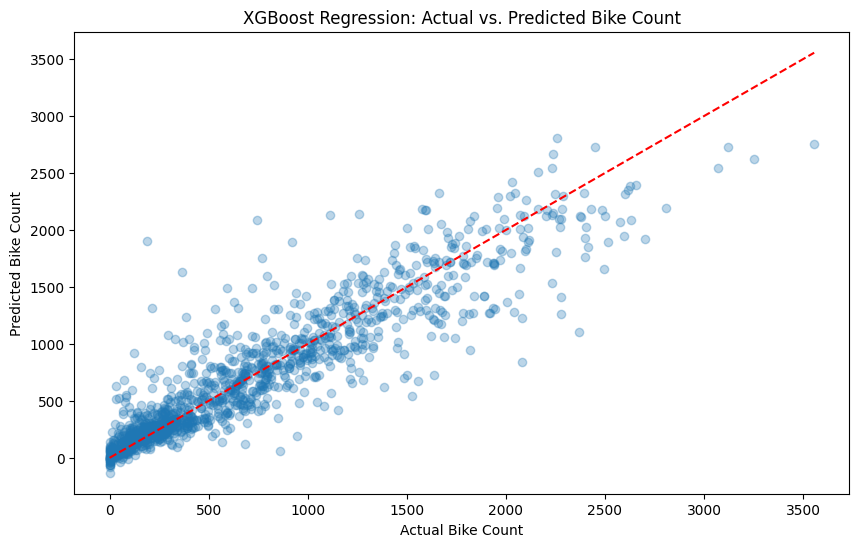

In [101]:
import xgboost as xgb

# Initialize and train the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regression - Mean Squared Error: {mse_xgb:.2f}")
print(f"XGBoost Regression - R-squared: {r2_xgb:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('XGBoost Regression: Actual vs. Predicted Bike Count')
plt.show()

### Boosting Models: AdaBoost Regression

Now, let's implement AdaBoost (Adaptive Boosting) Regressor. AdaBoost works by training a sequence of weak learners (typically decision trees) on repeatedly modified versions of the data. The predictions from all weak learners are then combined through a weighted majority vote (or sum) to produce the final prediction.

AdaBoost Regression - Mean Squared Error: 106613.41
AdaBoost Regression - R-squared: 0.74


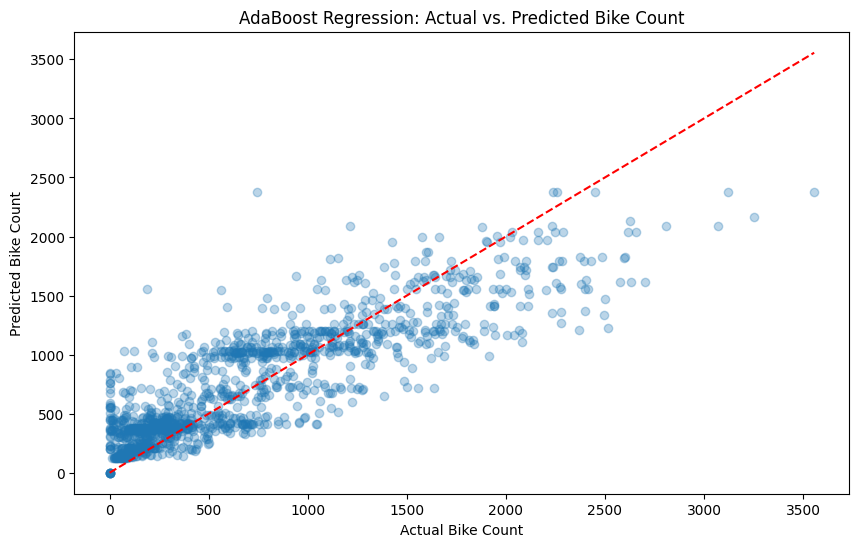

In [102]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Initialize a base estimator
base_estimator_ada = DecisionTreeRegressor(max_depth=4, random_state=42)

# Initialize and train the AdaBoost Regressor model
adaboost_model = AdaBoostRegressor(estimator=base_estimator_ada, n_estimators=100, learning_rate=0.1, random_state=42)
adaboost_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_adaboost = adaboost_model.predict(X_test_scaled)

# Evaluate the model
mse_adaboost = mean_squared_error(y_test, y_pred_adaboost)
r2_adaboost = r2_score(y_test, y_pred_adaboost)

print(f"AdaBoost Regression - Mean Squared Error: {mse_adaboost:.2f}")
print(f"AdaBoost Regression - R-squared: {r2_adaboost:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_adaboost, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('AdaBoost Regression: Actual vs. Predicted Bike Count')
plt.show()

### Voting Regressor Model

Let's implement a Voting Regressor. This is an ensemble meta-estimator that trains several base regressors on the same dataset and aggregates their individual predictions (e.g., by averaging) to form a final prediction. This often helps to reduce variance and improve generalization error.

Voting Regressor - Mean Squared Error: 66744.60
Voting Regressor - R-squared: 0.84


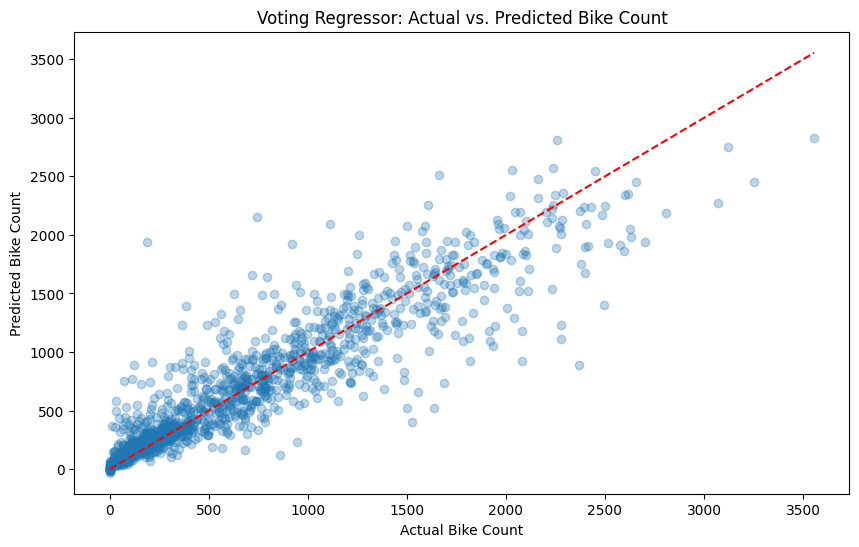

In [80]:
from sklearn.ensemble import VotingRegressor

# Using some of the better performing models as base estimators
estimators = [
    ('random_forest', rf_model),
    ('xgboost', xgb_model),
    ('bagging', bagging_model),
    ('knn', knn_model)
]

# Initialize and train the Voting Regressor model
voting_model = VotingRegressor(estimators=estimators, n_jobs=-1)
voting_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_voting = voting_model.predict(X_test_scaled)

# Evaluate the model
mse_voting = mean_squared_error(y_test, y_pred_voting)
r2_voting = r2_score(y_test, y_pred_voting)

print(f"Voting Regressor - Mean Squared Error: {mse_voting:.2f}")
print(f"Voting Regressor - R-squared: {r2_voting:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_voting, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('Voting Regressor: Actual vs. Predicted Bike Count')
plt.show()

### Clustering: K-Means

Let's implement K-Means clustering. K-Means is a popular iterative clustering algorithm that aims to partition `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid). Unlike DBSCAN, K-Means requires you to specify the number of clusters (`k`) beforehand. Similar to DBSCAN, this is for discovering patterns and not for predicting the `bike_count`.

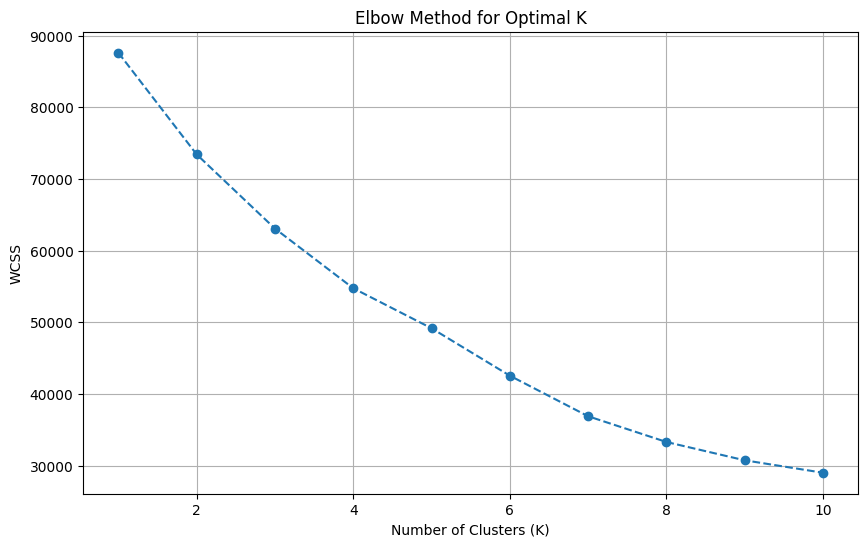

In [81]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Re-scale the entire dataset for clustering purposes
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# Determine optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


## Overall Prediction Accuracy (R-squared) Plot as Percentage

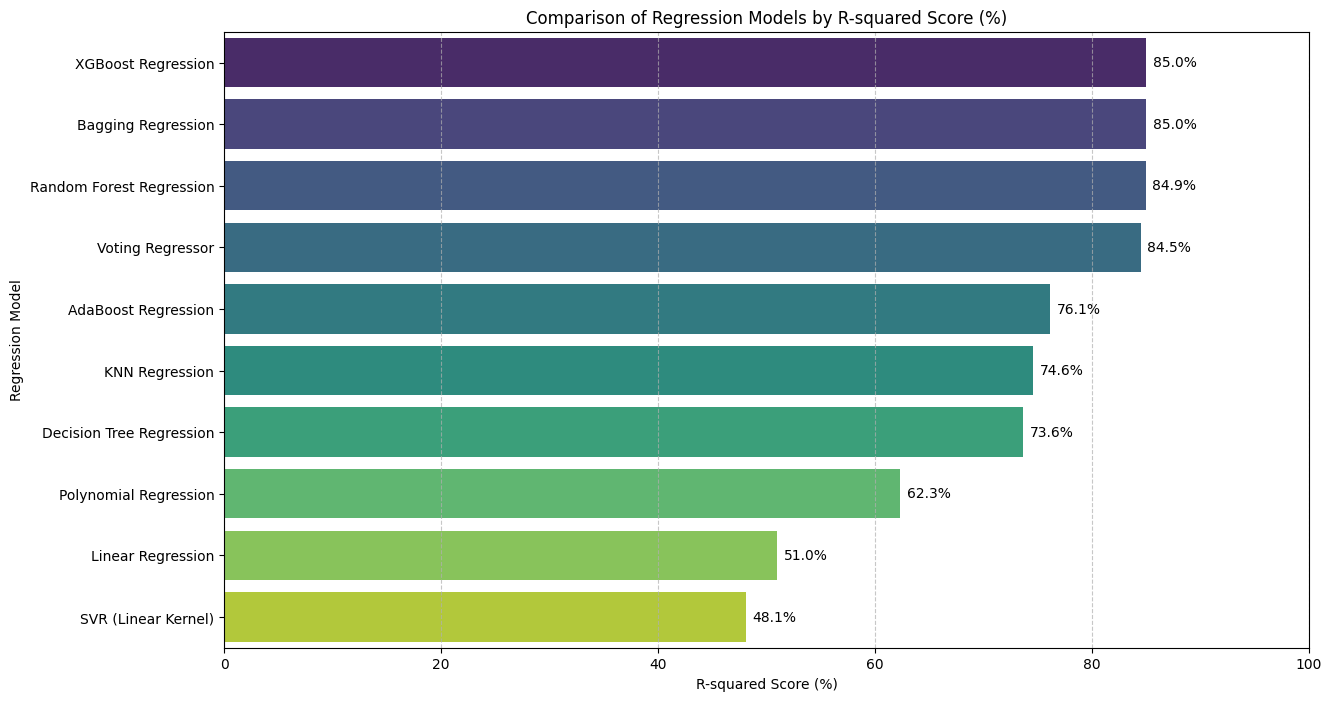

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of the R-squared DataFrame to avoid modifying the original
r2_df_percent = r2_df.copy()
# Convert R-squared values to percentages
r2_df_percent['R-squared'] = r2_df_percent['R-squared'] * 100

# Plot the R-squared values as percentages
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='R-squared', y='Model', hue='Model', data=r2_df_percent, palette='viridis', legend=False)
plt.xlabel('R-squared Score (%)')
plt.ylabel('Regression Model')
plt.title('Comparison of Regression Models by R-squared Score (%)')
plt.xlim(0, 100) # R-squared values as percentages are between 0 and 100
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add percentage labels on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=5)

plt.show()